Model scispaCy niedostępny, używam mechanizmu EntityRuler (fallback).
Próbka danych po wyczyszczeniu:


,label,clean
0,resp,ct chest shows right lower lobe consolidation ...
1,neuro,mri brain demonstrates small ischemic focus in...
2,ortho,x-ray pelvis reveals displaced femoral neck fr...
3,gastro,abdominal ultrasound shows gallstones without ...
4,onco,ct abdomen identifies liver metastases and enl...



Wyniki klasyfikacji
Accuracy: 0.0
Raport klasyfikacji:
               precision    recall  f1-score   support

       neuro       0.00      0.00      0.00       1.0
        onco       0.00      0.00      0.00       1.0
        resp       0.00      0.00      0.00       0.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0


Podświetlenie encji w tekstach:
- RESP: [CT<TEST>] chest shows right lower lobe consolidation suggestive of [PNEUMONIA<DISEASE>] no pleural [EFFUSION<DISEASE>]
- NEURO: [MRI<TEST>] brain demonstrates small [ISCHEMIC FOCUS<DISEASE>] in left parietal lobe no [HEMORRHAGE<DISEASE>] detected
- ORTHO: [X-RAY<TEST>] pelvis reveals displaced femoral neck [FRACTURE<DISEASE>] recommended orthopedic fixation
- GASTRO: abdominal [ULTRASOUND<TEST>] shows [GALLSTONES<DISEASE>] without bile duct dilatation
- ONCO: [CT<TEST>] abdomen identifies liver [METASTASES<DISEASE>

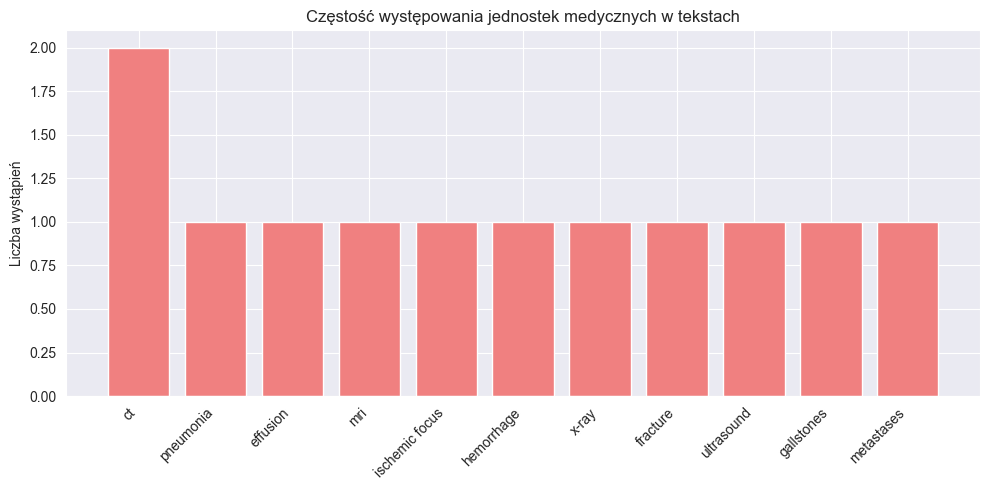

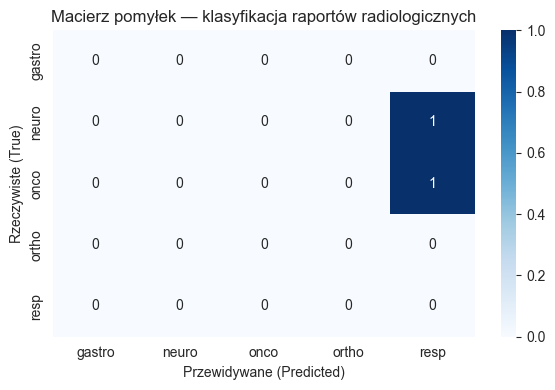

In [2]:

import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

try:
    import spacy
    nlp = spacy.load("en_core_sci_sm")
    SCISPACY_AVAILABLE = True
    print("Został załadowany model medyczny scispaCy (en_core_sci_sm).")
except Exception as e:
    SCISPACY_AVAILABLE = False
    import spacy
    from spacy.lang.en import English
    print("Model scispaCy niedostępny, używam mechanizmu EntityRuler (fallback).")

plt.rcParams["figure.figsize"] = (8, 5)

# Przygotowanie danych tekstowych
# Wczytanie zbioru danych
data =[
    ("CT chest shows right lower lobe consolidation suggestive of pneumonia. No pleural effusion.", "resp"),
    ("MRI brain demonstrates small ischemic focus in left parietal lobe. No hemorrhage detected.", "neuro"),
    ("X-ray pelvis reveals displaced femoral neck fracture. Recommended orthopedic fixation.", "ortho"),
    ("Abdominal ultrasound shows gallstones without bile duct dilatation.", "gastro"),
    ("CT abdomen identifies liver metastases and enlarged lymph nodes.", "onco")
]
df = pd.DataFrame(data, columns=["text", "label"])

# Funkcja czyszcząca dane
def clean_text(s):
    s = s.lower()
    s = s.replace("\n", " ").replace("\t", " ")
    s = re.sub(r"https?://\S+", " ", s)

    s = s.translate(str.maketrans("", "", string.punctuation.replace("-", "")))
    s = re.sub(r"\s+", " ", s).strip()
    return s

df["clean"] = df["text"].apply(clean_text)
# Tokenizacja
df["tokens"] = df["clean"].str.split()
print("Próbka danych po wyczyszczeniu:")
display(df[['label', 'clean']].head())

#Rozpoznawanie jednostek medycznych (NER)

if not SCISPACY_AVAILABLE:

    nlp = English()
    ruler = nlp.add_pipe("entity_ruler")
    patterns =[
        {"label": "DISEASE", "pattern": "pneumonia"},
        {"label": "DISEASE", "pattern": "effusion"},
        {"label": "DISEASE", "pattern": "ischemic focus"},
        {"label": "DISEASE", "pattern": "hemorrhage"},
        {"label": "DISEASE", "pattern": "fracture"},
        {"label": "DISEASE", "pattern": "gallstones"},
        {"label": "DISEASE", "pattern": "metastases"},
        {"label": "TEST", "pattern": "ct"},
        {"label": "TEST", "pattern": "mri"},
        {"label": "TEST", "pattern": "x-ray"},
        {"label": "TEST", "pattern": "ultrasound"}
    ]
    ruler.add_patterns(patterns)

entities_list = []
all_extracted_entities = []

for text in df["clean"]:
    doc = nlp(text)

    ents =[(ent.text, ent.label_) for ent in doc.ents]
    entities_list.append(ents)

    all_extracted_entities.extend([ent.text for ent in doc.ents])

df["entities"] = entities_list



#Klasyfikacja dokumentów

X = df["clean"].values
y = df["label"].values

# Wektoryzacja TF-IDF
vectorizer = TfidfVectorizer(ngram_range=(1,2), min_df=1)
X_vec = vectorizer.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y, test_size=0.4, random_state=42
)

# Klasyfikator
clf = LinearSVC(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("\nWyniki klasyfikacji")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Raport klasyfikacji:\n", classification_report(y_test, y_pred, zero_division=0))



#Wizualizacja i interpretacja wyników


# Wyświetlenie fragmentów tekstu z oznaczonymi jednostkami (podświetlenie)
def highlight_entities(text, entities):
    out = text
    entities_sorted = sorted(entities, key=lambda x: len(x[0]), reverse=True)
    for ent, label in entities_sorted:
        out = out.replace(ent, f"[{ent.upper()}<{label}>]")
    return out

print("\nPodświetlenie encji w tekstach:")
for i in range(len(df)):
    t = df.loc[i, "clean"]
    ents = df.loc[i, "entities"]
    print(f"- {df.loc[i, 'label'].upper()}: {highlight_entities(t, ents)}")

#Wykres: Częstość występowania encji
ent_counts = Counter(all_extracted_entities)
if ent_counts:
    plt.figure(figsize=(10, 5))
    # Wybieramy najpopularniejsze encje
    items, counts = zip(*ent_counts.most_common())
    plt.bar(items, counts, color='lightcoral')
    plt.xticks(rotation=45, ha='right')
    plt.title("Częstość występowania jednostek medycznych w tekstach")
    plt.ylabel("Liczba wystąpień")
    plt.tight_layout()
    plt.show()

all_labels = np.unique(y)

cm = confusion_matrix(y_test, y_pred, labels=all_labels)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=all_labels, yticklabels=all_labels)
plt.title("Macierz pomyłek — klasyfikacja raportów radiologicznych")
plt.ylabel("Rzeczywiste (True)")
plt.xlabel("Przewidywane (Predicted)")
plt.tight_layout()
plt.show()